# Stage 5 — CDC validation (spatial checkpoint)

Stage 3 wrote a per-county detection table (`county_detections.parquet`); Stage 2
tidied the CDC county-level establishment workbook. Stage 5 joins them on
**5-digit FIPS** and classifies every county into three interpretable buckets.

All logic lives in `src/stage5.py`; all knobs live in `src/config.py`. This
notebook runs that module and reports the metrics and map. We read **only** from
`data/processed/`; `data/raw/` and `data/interim/` are untouched.

**Honest framing (non-negotiable):** CDC "established" is a single cumulative,
sticky 2025 snapshot. This comparison is a *spatial checkpoint*, **not**
temporal validation. Leading-edge counties are **candidates to watch**, not
confirmed expansion. Blind spots reflect **our observer coverage**, not absence
of ticks.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

# Make src/ importable (config.py, stage4.py / stage5.py) regardless of cwd.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import config

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
config.VIZ_DIR.mkdir(parents=True, exist_ok=True)

import stage5

print("Stage 5 config knobs in play this run:")
print(f"  STAGE5_DETECTION_MIN_OBS     = {config.STAGE5_DETECTION_MIN_OBS}")
print(f"  STAGE5_COMPARISON_MODE       = {config.STAGE5_COMPARISON_MODE}")
print(f"  STAGE5_REPORTED_TREATMENT    = {config.STAGE5_REPORTED_TREATMENT}")
print(f"  CDC_ESTABLISHED_STATUS_VALUE = {config.CDC_ESTABLISHED_STATUS_VALUE!r}")


Stage 5 config knobs in play this run:
  STAGE5_DETECTION_MIN_OBS     = 2
  STAGE5_COMPARISON_MODE       = cumulative
  STAGE5_REPORTED_TREATMENT    = separate
  CDC_ESTABLISHED_STATUS_VALUE = 'Established'


## 1. Run the Stage 5 pipeline

`stage5.run_stage5()` builds the detection summary, joins to CDC by FIPS,
classifies counties, computes agreement metrics, and writes the table, JSON
metrics, choropleth figure, and web validation layer.


In [2]:

out = stage5.run_stage5(write=True)

validation = out["validation"]
metrics = out["metrics"]
highlights = out["highlights"]

print(f"Universe: {metrics['n_universe_counties']:,} counties")
print(f"Detected (cumulative bar): {metrics['n_detected']:,}")
print(f"CDC established: {metrics['n_cdc_established']:,}")
print(f"\nFigure -> {out['figure']}")
print(f"Web layer -> {out['web_layer']}")


16:01:20 | INFO    | Loaded inputs: 5120 county-windows (1103 unique counties) | CDC table 3110 counties (1139 established, 635 reported, 1336 no-records)


16:01:20 | INFO    | Detection summary: 1103 counties with any detection; bar = n_total >= 2; mode = cumulative -> 655 detected (cumulative=655, recent=469)


16:01:21 | INFO    | Classification: {'neither': 1824, 'blind_spot': 631, 'confirmed': 508, 'leading_edge_reported': 106, 'leading_edge_no_records': 41}


C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\src\stage5.py:208: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged[col] = merged[col].fillna(fill).astype(bool)
C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\src\stage5.py:208: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged[col] = merged[col].fillna(fill).astype(bool)
C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\src\stage5.py:208: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(

16:01:23 | INFO    | Loaded county polygons from cache (3221 features)


...

16:01:23 | INFO    | Wrote validation table + metrics -> C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\data\processed


16:01:37 | INFO    | Wrote figure -> C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\reports\figures\stage5_validation_choropleth.png


16:01:38 | INFO    | Created 1,286 records


16:01:38 | INFO    | Web layer: 1286 county features (established OR detected) -> county_validation.geojson (900 KB), validation.js (794 KB)


Universe: 3,110 counties
Detected (cumulative bar): 655
CDC established: 1,139

Figure -> C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\reports\figures\stage5_validation_choropleth.png
Web layer -> C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\viz\data\validation.js


## 2. Detection bar and cumulative footprint

A county counts as **detected** in a window only when iNat+NEON observations
clear `STAGE5_DETECTION_MIN_OBS` (default **2** → "more than one observation"),
mirroring CDC's establishment bar so a single stray does not register.

The comparison uses the **cumulative ever-detected** set: the union over rolling
windows of counties that cleared the bar at least once (`STAGE5_COMPARISON_MODE
= "cumulative"`). A `"recent"` mode exists in config but defaults off — it would
restrict to the latest window only.


In [3]:

detections, _ = stage5.load_inputs()
summary = stage5.build_detection_summary(detections)

thr = config.STAGE5_DETECTION_MIN_OBS
print(f"Detection threshold: >= {thr} observations in a window")
print(f"Counties ever clearing bar (cumulative): {int(summary['detected'].sum()):,}")
print(f"Counties detected in latest window only: {int(summary['detected_recent'].sum()):,}")

peak = summary["peak_window_obs"]
print(f"\nPeak window obs per county: median={peak.median():.0f}, max={peak.max():.0f}")
print(f"  counties with peak == 1 (would fail bar): {(peak == 1).sum():,}")

summary[["detected", "detected_cumulative", "detected_recent",
         "peak_window_obs", "n_windows_detected"]].describe().T


16:01:38 | INFO    | Loaded inputs: 5120 county-windows (1103 unique counties) | CDC table 3110 counties (1139 established, 635 reported, 1336 no-records)


16:01:38 | INFO    | Detection summary: 1103 counties with any detection; bar = n_total >= 2; mode = cumulative -> 655 detected (cumulative=655, recent=469)


Detection threshold: >= 2 observations in a window
Counties ever clearing bar (cumulative): 655
Counties detected in latest window only: 469

Peak window obs per county: median=2, max=3104
  counties with peak == 1 (would fail bar): 448


,count,mean,std,min,25%,50%,75%,max
peak_window_obs,1103.0,17.941976,161.472715,1.0,1.0,2.0,4.0,3104.0
n_windows_detected,1103.0,2.438803,2.769686,0.0,0.0,2.0,4.0,10.0


## 3. FIPS join and the three buckets (+ "neither")

Join key = **5-digit county FIPS** (zero-padded on both sides). Universe =
outer union of every CDC county and every county in our detection table.

| category | meaning |
|---|---|
| **confirmed** | detected **and** CDC-established — agreement |
| **leading edge · reported** | detected, not established, CDC status = *Reported* — partial corroboration |
| **leading edge · no records** | detected, not established, CDC = *No records* — stronger frontier candidate |
| **blind spot** | CDC-established, **not** detected — our coverage gap |
| **neither** | not detected, not established — background |

Counties detected but absent from the CDC table are treated as CDC *No records*
(`in_cdc_table=False`).


In [4]:

cats = metrics["category_counts"]
cm = metrics["confusion_matrix"]

print("Category counts:")
for k, v in cats.items():
    label = config.STAGE5_CATEGORY_LABELS.get(k, k)
    print(f"  {label:55s} {v:5d}")

print("\nConfusion matrix (detected vs CDC-established):")
print(f"  TP confirmed          {cm['TP_confirmed']:5d}")
print(f"  FP leading edge       {cm['FP_leading_edge']:5d}"
      f"  (reported {cm['FP_leading_edge_reported']},"
      f" no-records {cm['FP_leading_edge_no_records']})")
print(f"  FN blind spot         {cm['FN_blind_spot']:5d}")
print(f"  TN neither            {cm['TN_neither']:5d}")

validation.groupby("category").agg(
    counties=("county_fips", "count"),
    median_peak_obs=("peak_window_obs", "median"),
    median_inat=("n_inat_total", "median"),
).sort_values("counties", ascending=False)


Category counts:
  Confirmed (detected & CDC-established)                    508
  Leading edge · CDC reported (partial corroboration)       106
  Leading edge · CDC no records (frontier candidate)         41
  Blind spot (CDC-established, we missed)                   631
  Neither                                                  1824

Confusion matrix (detected vs CDC-established):
  TP confirmed            508
  FP leading edge         147  (reported 106, no-records 41)
  FN blind spot           631
  TN neither             1824


,counties,median_peak_obs,median_inat
category,,,
neither,1824,0.0,0.0
blind_spot,631,0.0,0.0
confirmed,508,4.0,13.0
leading_edge_reported,106,3.0,11.0
leading_edge_no_records,41,2.0,7.0


## 4. Recall and precision — what each means

**Recall** = of CDC-established counties, the share we detected = TP / (TP + FN).
Answers: *"Did we find the counties CDC already calls established?"*

**Precision (strict)** = of our detected counties, the share CDC confirms =
TP / (TP + FP). Answers: *"When we say detected, how often does CDC agree?"*

**Precision (lenient)** additionally credits detected counties where CDC status
is *Reported* (partial corroboration) in the numerator — useful context, not a
second headline.

Low recall → blind spots (coverage). Low strict precision → many leading-edge
counties ahead of (or uncorroborated by) the CDC snapshot.


In [5]:

print(metrics["framing"])
print()
print(f"Recall of CDC established     {metrics['recall_of_cdc_established']:.1%}")
print(f"Precision (strict)            {metrics['precision_strict']:.1%}")
print(f"Precision (lenient + reported) {metrics['precision_lenient_incl_reported']:.1%}")
print()
print("Detection bar settings:", metrics["detection_bar"])


Spatial checkpoint against the CDC 2025 cumulative established snapshot -- NOT a temporal validation. Leading-edge counties are candidates to watch; blind spots reflect our observer coverage.

Recall of CDC established     44.6%
Precision (strict)            77.6%
Precision (lenient + reported) 93.7%

Detection bar settings: {'min_obs': 2, 'comparison_mode': 'cumulative', 'reported_treatment': 'separate'}


## 5. Leading-edge candidates and the validation map

**Leading-edge** counties are the interesting disagreement: we see repeated
lone star observations where CDC has not (yet) labeled establishment. The
*no-records* sub-bucket is a stronger frontier signal than *reported* (CDC
already notes the species without full establishment).

The choropleth colours confirmed (blue), leading edge (amber / red split), and
blind spots (grey), leaving the "neither" universe faint so the signal reads.


Top leading-edge counties (ranked: no-records first, then peak obs):


,county_fips,state,county,category,cdc_status,peak_window_obs,n_inat_total,n_neon_total,last_detected_window,rep_lat
0,20049,KS,Elk County,leading_edge_no_records,No records,10,14,0,2024-2026,37.431531
1,20035,KS,Cowley County,leading_edge_no_records,No records,8,24,0,2024-2026,37.151008
2,51165,VA,Rockingham County,leading_edge_no_records,No records,7,26,0,2024-2026,38.538161
3,29139,MO,Montgomery County,leading_edge_no_records,No records,6,24,0,2024-2026,38.919031
4,37029,NC,Camden County,leading_edge_no_records,No records,5,15,0,2024-2026,36.327836
5,37169,NC,Stokes County,leading_edge_no_records,No records,4,20,0,2024-2026,36.443681
6,20013,KS,Brown County,leading_edge_no_records,No records,4,16,0,2024-2026,39.768252
7,37157,NC,Rockingham County,leading_edge_no_records,No records,4,13,0,2024-2026,36.442803
8,47061,TN,Grundy County,leading_edge_no_records,No records,3,11,0,2023-2025,35.362862
9,22119,LA,Webster Parish,leading_edge_no_records,No records,3,9,0,2024-2026,32.650583


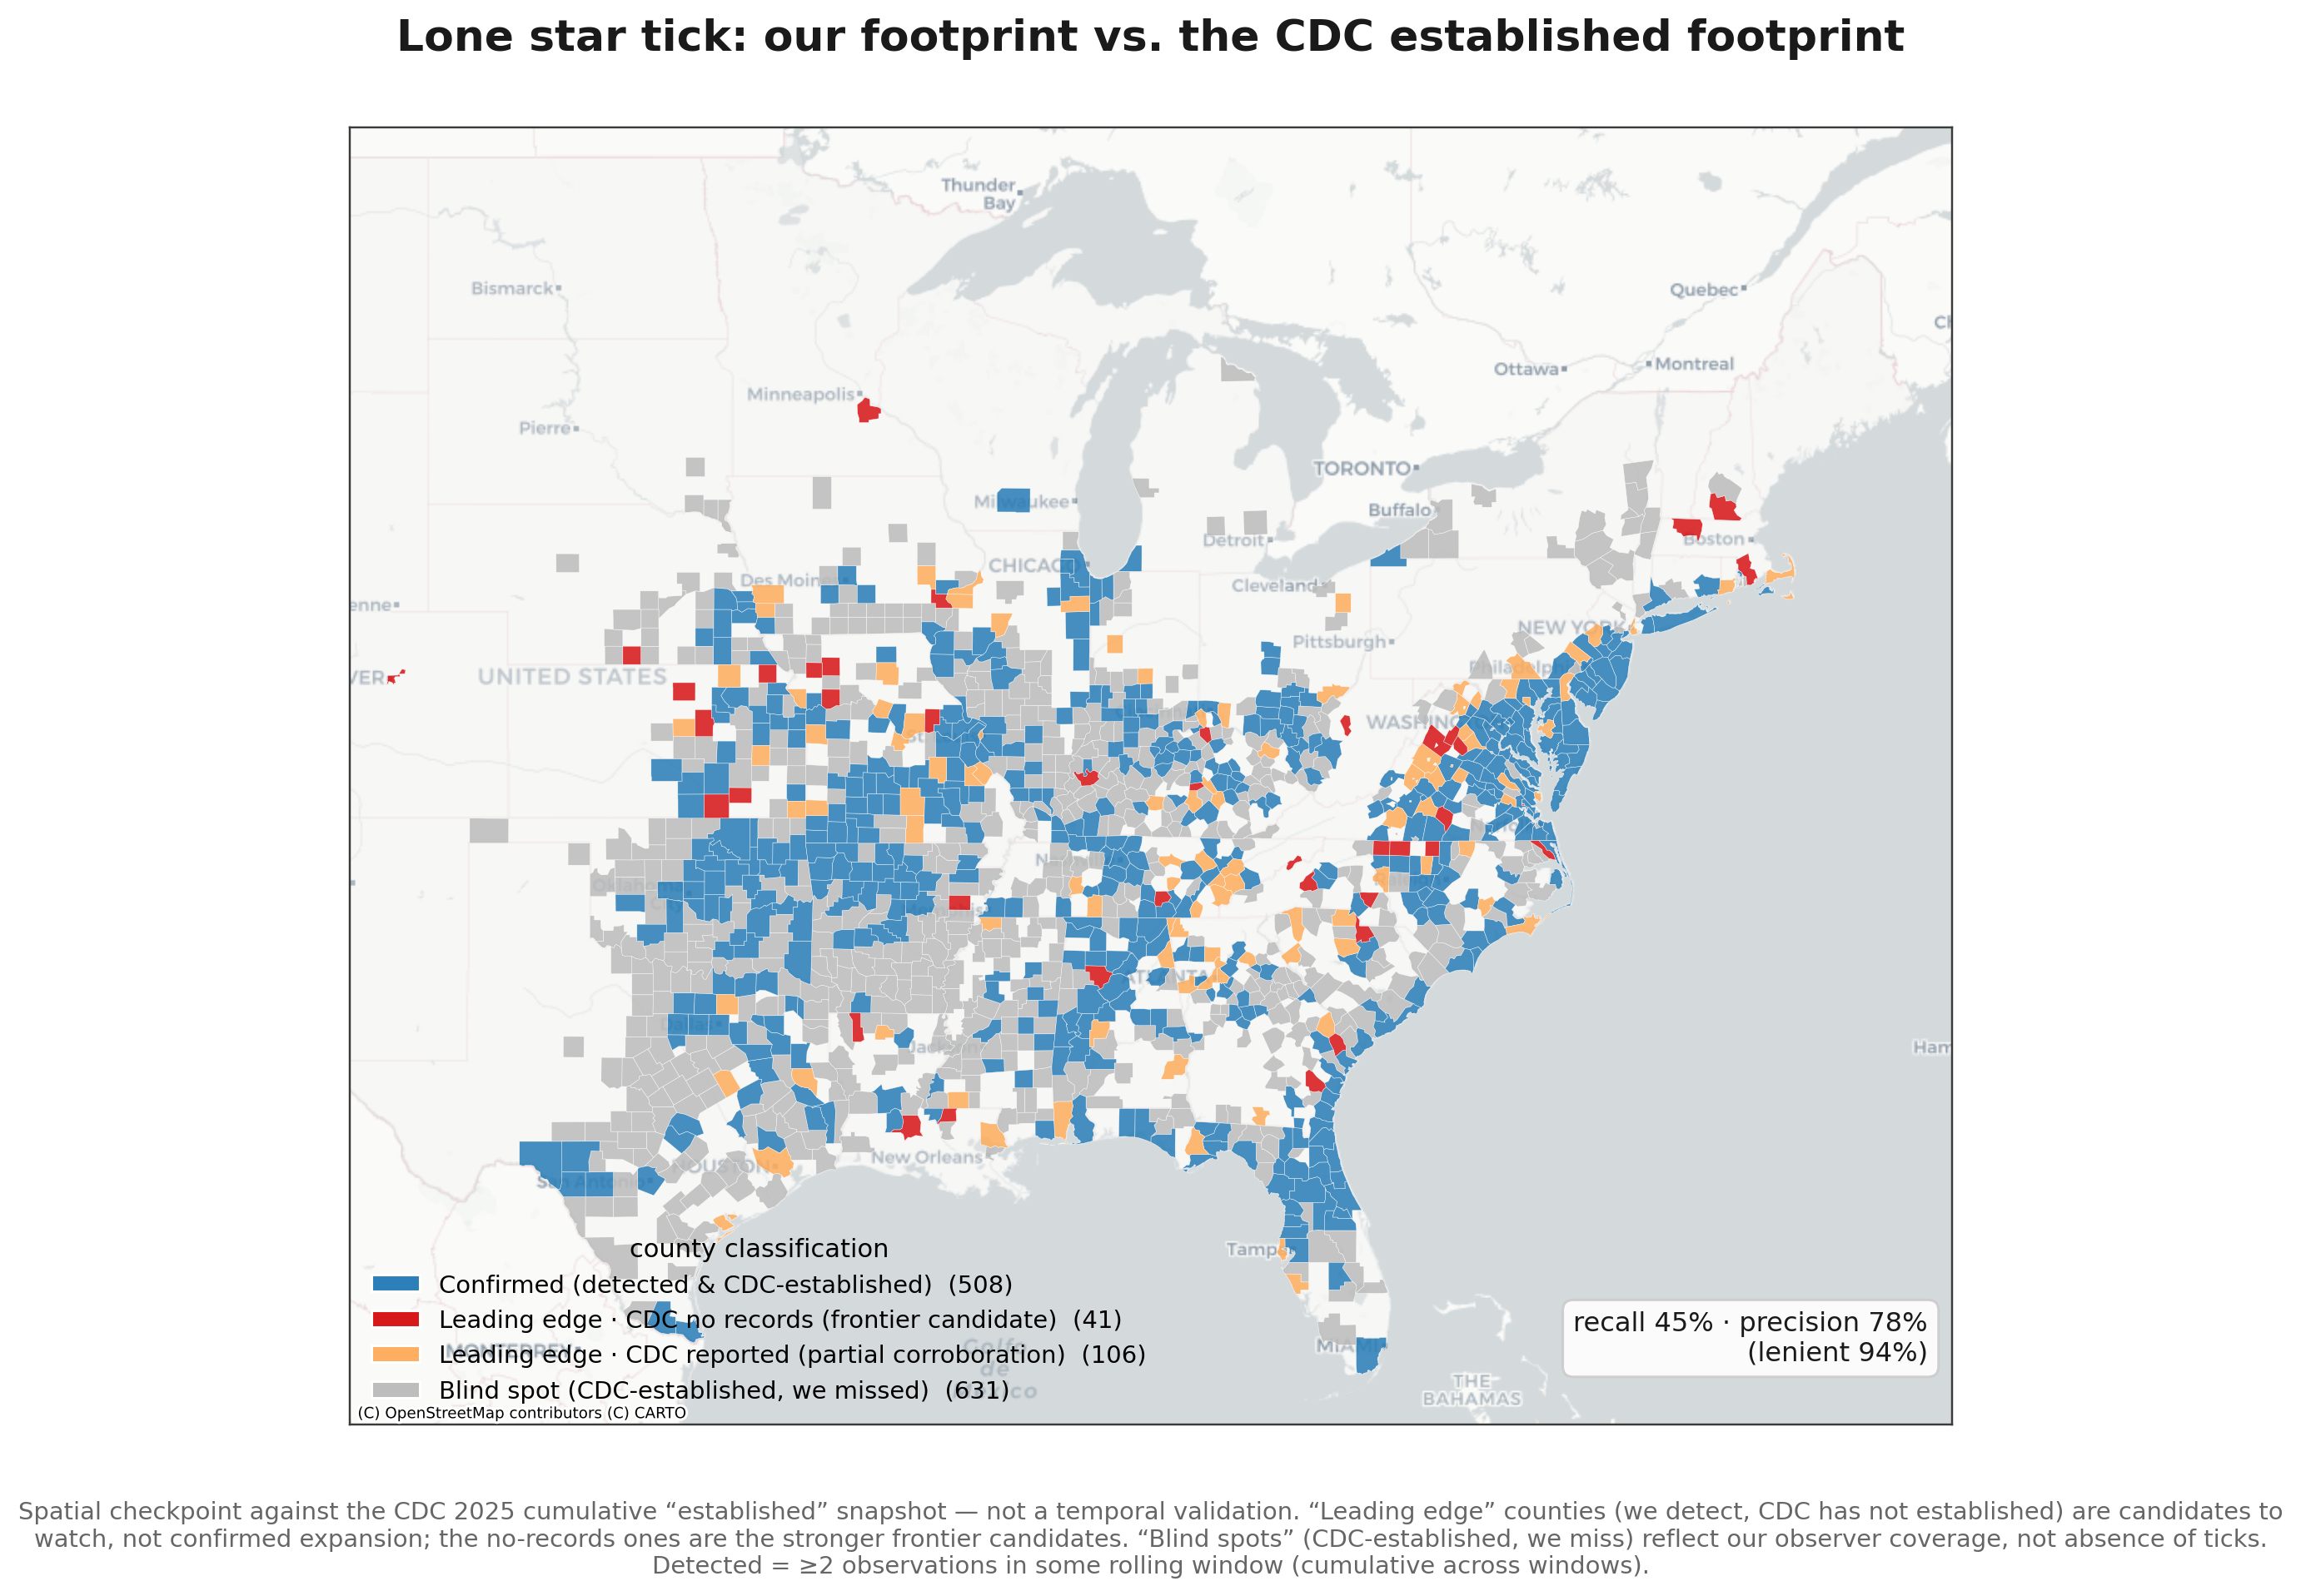

In [6]:

print("Top leading-edge counties (ranked: no-records first, then peak obs):")
display(highlights)

path = out["figure"]
display(Image(filename=str(path)))


## 6. Outputs written + honest limits

Written to `data/processed/`:

| file | contents |
|---|---|
| `county_validation.parquet` / `.csv` | per-county detection + CDC status + category |
| `stage5_validation_metrics.json` | confusion matrix, recall, precision, bucket counts |

Written to `reports/figures/` and `viz/data/`:

| file | contents |
|---|---|
| `stage5_validation_choropleth.png` | three-category map |
| `county_validation.geojson`, `validation.js` | interactive validation layer |

**What this does NOT prove:** because CDC status is a cumulative 2025 sticky
snapshot, a leading-edge county may reflect real ahead-of-CDC expansion *or*
taxonomic noise, mis-ID, or CDC lag — we flag candidates, we do not claim
establishment. Blind spots likewise mean *we* did not accumulate enough
observations, not that ticks are absent.
